# 02 — Pré-processamento dos Metadados

> **Etapa 1 do refactor.** Este notebook trata **apenas** o CSV de metadados clínicos.
> As imagens serão tratadas no notebook `03_preprocessamento_pdi.ipynb`. A junção
> das duas fontes acontece no notebook de extração de features.

## O que este notebook faz

1. Carrega o metadata bruto.
2. Remove colunas com **data leakage** causal reverso (`biopsed`).
3. Remove o bloco de 13 colunas **MNAR outcome-dependent** — decisão fundamentada
   em literatura de imputação (ver seção 2).
4. Cria feature derivada `symptom_count` (contagem de sintomas ABCDE-like).
5. Faz **split por paciente** (`StratifiedGroupKFold`) em ~64/16/20 train/val/test.
6. Ajusta um `Pipeline` sklearn (OHE + StandardScaler) **somente no treino**.
7. Transforma os 3 splits e **persiste em disco** junto com os artefatos
   (pipeline, label encoder, metadados do split).

## O que este notebook NÃO faz

- Não toca em imagens.
- Não imputa valores (o dataset fica 100% completo após a etapa 3).
- Não faz SMOTE / oversampling (decisão do modelo, não do pré-processamento).
- Não faz feature selection (modelo decide).
- Não extrai features de PDI (próximo notebook).

## Saída final

```
data/processed/metadata/
├── train.parquet        # features + target + patient_id
├── val.parquet
├── test.parquet
├── pipeline.joblib      # ColumnTransformer ajustado no treino
├── label_encoder.joblib # LabelEncoder da target
├── feature_names.json   # nomes das colunas após transformação
└── split_info.json      # metadados dos splits (contagens, seeds, etc)
```


## 1. Setup

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

ROOT         = Path('..').resolve()
RAW_META     = ROOT / 'data' / 'raw' / 'metadata.csv'
PROC_DIR     = ROOT / 'data' / 'processed' / 'metadata'
PROC_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
print('Diretório de saída:', PROC_DIR)


Diretório de saída: /home/fonsek/CODE/pad-ufes-skin-classification/data/processed/metadata


## 2. Carregamento e inspeção inicial

Carregamos o metadata bruto e fazemos uma checagem rápida antes de qualquer transformação.


In [2]:
df = pd.read_csv(RAW_META)
print(f'shape bruto: {df.shape}')
print(f'pacientes  : {df.patient_id.nunique()}')
print(f'lesões     : {df.lesion_id.nunique()}')
print(f'imagens    : {len(df)}')
print()
print('Classes:')
print(df.diagnostic.value_counts())
print()
print('Colunas:', df.columns.tolist())


shape bruto: (2298, 26)
pacientes  : 1373
lesões     : 1641
imagens    : 2298

Classes:
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64

Colunas: ['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id', 'biopsed']


## 3. Decisão 1 — Remover `biopsed` (data leakage)

**O problema.** A coluna `biopsed` indica se a lesão foi biopsiada. Na coleta,
uma lesão só é biopsiada **depois** que o médico já suspeita de malignidade.
Ou seja, `biopsed` é uma consequência causal do diagnóstico, não um preditor dele.

**Evidência empírica** (do EDA no notebook 01):

| classe | biopsed=True | biopsed=False |
|---|---:|---:|
| BCC  | 845 | 0 |
| MEL  |  52 | 0 |
| SCC  | 192 | 0 |
| ACK  | 178 | 552 |
| NEV  |  60 | 184 |
| SEK  |  15 | 220 |

**100% das lesões malignas** (BCC, MEL, SCC) foram biopsiadas. Manter essa coluna
como feature daria métricas infladas que desapareceriam na hora do deploy real
(em triagem clínica, a pergunta *é* "devo biopsiar?", antes da biópsia acontecer).

**Decisão:** drop definitivo.


In [3]:
LEAK_COLS = ['biopsed']
df = df.drop(columns=LEAK_COLS)
print(f'shape após drop de leak: {df.shape}')


shape após drop de leak: (2298, 25)


## 4. Decisão 2 — Remover o bloco MNAR outcome-dependent (13 colunas)

**O problema.** 35% das linhas (804 de 2298) têm **exatamente as mesmas 13
colunas** faltando em bloco, formando um padrão estruturado, não aleatório:

```
smoke, drink, pesticide, gender, skin_cancer_history, cancer_history,
has_piped_water, has_sewage_system, fitspatrick, diameter_1, diameter_2,
background_father, background_mother
```

A evidência empírica do EDA (notebook `01`) mostra uma correlação determinística
entre o padrão de missingness e o diagnóstico:

| Observação | Números | Implicação |
|---|---|---|
| Linhas com 13 NaN em bloco | 804 | "Trilha short-form" |
| Linhas 100% completas | 1474 | "Trilha long-form" |
| `biopsed=False` em short-form | **100%** (824/824) | Quem fez short-form nunca foi biopsiado |
| Malignas em short-form | **0** (0 BCC, 0 MEL, 0 SCC) | Quem fez short-form **nunca é maligno** |
| Malignas em long-form | 1089 (100% de BCC+MEL+SCC) | Todos os malignos estão na long-form |

### O que é MNAR e por que isso importa

Missingness se classifica em três tipos ([Rubin, 1976](https://doi.org/10.1093/biomet/63.3.581)):

- **MCAR (Missing Completely At Random)** — a ausência não depende de nada.
  Exemplo: balança que falha aleatoriamente em 5% das medições. Qualquer
  tratamento funciona.
- **MAR (Missing At Random)** — a ausência depende de variáveis **observadas**.
  Exemplo: homens deixam "peso" em branco com mais frequência que mulheres.
  Imputação multivariada (MICE, missForest) funciona se o imputer usar `gender`.
- **MNAR (Missing Not At Random)** — a ausência depende do **próprio valor
  faltante** ou de uma **variável não observada** (incluindo o outcome).
  Exemplo: pessoas com renda muito alta não respondem "qual sua renda?".
  **Matematicamente insolúvel sem assunções externas.**

O caso mais grave é o **MNAR outcome-dependent**: quando a probabilidade de
estar faltando depende do target que queremos prever.

### Por que as 13 colunas do PAD-UFES são MNAR outcome-dependent

A cadeia causal, reconstruída pelos dados:

```
  Lesão suspeita ──→  Biópsia pedida ──→  Formulário longo ──→  BCC/SCC/MEL muito provável
  Lesão benigna ──→  Sem biópsia    ──→  Formulário curto ──→  ACK/NEV/SEK muito provável
```

A ausência dos 13 campos **é consequência causal do protocolo clínico**, e o
protocolo é acionado pela **suspeita diagnóstica**, que é o próprio outcome.
A cadeia `missingness → protocolo → suspeita → diagnóstico` é determinística:
**saber que uma linha está no short-form permite afirmar com 100% de certeza
que ela não é maligna**. Isso encaixa, textbook, na definição de MNAR
outcome-dependent.

### Por que imputar é errado neste caso (4 caminhos e suas refutações)

#### ❌ Caminho 1 — Imputação simples (mediana/moda)

Modelos não-lineares (Random Forest, GBM, redes neurais) **aprendem a reconhecer
a assinatura do imputer**. As 804 linhas imputadas ficam com o mesmíssimo valor
nas 13 colunas e o modelo aprende "se `smoke=moda AND drink=moda AND
fitspatrick=mediana AND diameter=mediana ...` → benigno com ~95% de certeza".
O leak não é apagado, só é mascarado.

> *"When missing fields are highly correlated with the outcome, this creates
> data leakage. Simple approaches like mean imputation are not good solutions
> for fixing this data leakage, as predictive models capable of modeling
> non-linear relationships will pick up on the problematic patterns."*
>
> — [Dealing with Leaky, Missing Data in a Production Environment (Towards Data Science)](https://towardsdatascience.com/dealing-with-leaky-missing-data-in-a-production-environment-d48304ad3b6b/)

#### ❌ Caminho 2 — Imputação multivariada (MICE / IterativeImputer / missForest)

MICE e missForest funcionam bem em MAR, mas **degradam severamente em blockwise
MNAR** — justamente o nosso padrão. Além disso, o imputer é treinado na
população long-form (enviesada para malignos suspeitos) e aplicado na população
short-form (benignos não suspeitos) — **é covariate shift dentro do próprio
dataset**, e o resultado é um valor sintético que não reflete a distribuição
real de nenhum dos dois grupos.

> *"missForest can produce severely biased regression coefficient estimates
> and downward biased confidence interval coverages, especially for highly
> skewed variables in nonlinear models. missForest should not be
> indiscriminately recommended as a panacea for imputing missing data,
> especially when data are highly skewed and/or outcome-dependent MAR."*
>
> — [Hong & Lynn, *Accuracy of random-forest-based imputation* (BMC Medical Research Methodology, 2020)](https://link.springer.com/article/10.1186/s12874-020-01080-1)

> *"When blockwise missingness was introduced in MNAR scenarios, KNN and MIDAS
> showed slightly higher imputation error, while MICE and MissForest showed
> more significant error rate increases."*
>
> — [Benchmarking ML Missing Data Imputation Methods in Large-Scale Mental Health Survey Databases (medRxiv, 2024)](https://www.medrxiv.org/content/10.1101/2024.05.13.24307231v1.full)

#### ❌ Caminho 3 — Missing indicator (flag `has_clinical_metadata`)

A ideia aparentemente inteligente é adicionar uma coluna booleana que sinaliza
"esta linha teve metadados coletados". Numa simulação específica de modelos
clínicos de predição, Sisk et al. mostram que **esse flag é especificamente
danoso quando a missingness correlaciona com o outcome** — que é o nosso caso
exato. Adicionar `has_clinical_metadata` é matematicamente equivalente a
re-adicionar `biopsed` (a própria coluna que removemos por leak), só que com
nome diferente.

> *"Missing indicators can improve model performance in many cases **but can be
> harmful under outcome-dependent missingness**."*
>
> — [Sisk et al., *Imputation and missing indicators for handling missing data in the development and deployment of clinical prediction models* (Diagnostic and Prognostic Research, 2023)](https://pmc.ncbi.nlm.nih.gov/articles/PMC10515473/)

#### ❌ Caminho 4 — Modelos generativos (GAIN, VAE, identifiable MNAR)

A linha de pesquisa mais recente tenta atacar MNAR com modelos generativos
profundos. O problema fundamental: para MNAR **a identificabilidade não é
garantida sem assunções fortes sobre o mecanismo de missingness**, e mesmo
papers que propõem garantias precisam de condições que o PAD-UFES não atende
(a distribuição latente precisa ser aproximadamente gaussiana, o mecanismo de
censoring precisa satisfazer "no self-censoring", etc.).

> *"Models tend to learn multiple non-unique complete data distributions that
> match the observed data. Their model's identifiability under MNAR is
> generally not guaranteed — meaning model parameters cannot be uniquely
> determined even with infinite data samples, hence the imputation results can
> still be biased."*
>
> — [Ma & Zhang, *Identifiable Generative Models for Missing Not at Random Data Imputation* (NeurIPS, 2021)](https://arxiv.org/abs/2110.14708)

Traduzindo: **nem com infinitos dados** dá para imputar esse padrão sem viés.
Não é um problema de "método mais inteligente"; é uma barreira matemática.

#### ❌ Caminho 5 — Dropar as 804 linhas short-form

Outra alternativa seria preservar as 13 colunas e dropar as 804 linhas sem
metadados. O problema: o dataset resultante (1474 linhas) conteria **só
lesões já triadas como suspeitas**. O modelo treinaria no universo
"lesões suspeitas o suficiente para biópsia" e **nunca veria** lesões benignas
óbvias — exatamente as que dominam a triagem dermatológica real. Resultado:
modelo inútil em produção (não sabe dizer "isso é tranquilo"), e com viés
invisível nas métricas de validação (porque a validação também é feita só em
lesões suspeitas).

### Por que dropar as colunas é a solução correta

1. **Preserva as 2298 linhas**, incluindo todas as 52 MELs (classe mais
   crítica). Nenhuma amostra é perdida.
2. **Elimina o proxy do protocolo de coleta** do feature set. O modelo
   aprende a classificar lesões a partir de features que existem **nas duas
   trilhas igualmente** (`age`, `region`, sintomas, imagem).
3. **Recupera o sinal real das colunas "úteis"** via features de PDI extraídas
   da imagem. A imagem está presente tanto no short-form quanto no long-form,
   então não sofre do viés de protocolo:

   | Coluna removida | Substituída no notebook `03` por |
   |---|---|
   | `fitspatrick` | Features de cor (LAB, HSV) da pele **perilesional** (fora da lesão). Fotótipo é literalmente tom de pele visível. |
   | `diameter_1`, `diameter_2` | `lesion_area_px`, `major_axis_px`, `minor_axis_px` calculados da máscara de segmentação |

   As outras 10 colunas (`smoke`, `drink`, `pesticide`, histórico, condições
   socioeconômicas, ancestralidade) não têm contrapartida visual e são
   descartadas definitivamente — são informações de anamnese que simplesmente
   não existem para 35% dos pacientes.

4. **É a única opção consistente com a literatura.** Todos os 4 caminhos
   alternativos acima são explicitamente contraindicados por pelo menos um
   paper peer-reviewed para o cenário MNAR outcome-dependent. Drop de colunas
   é o único caminho que não introduz leak nem viés oculto.

### Referências consolidadas

| # | Referência | O que estabelece |
|---|---|---|
| 1 | [Rubin, D. B. (1976). *Inference and missing data*. **Biometrika**, 63(3), 581–592](https://doi.org/10.1093/biomet/63.3.581) | Define MCAR/MAR/MNAR; paper fundador da teoria |
| 2 | [Ma & Zhang (2021). *Identifiable Generative Models for Missing Not at Random Data Imputation*. **NeurIPS**](https://arxiv.org/abs/2110.14708) | Prova que MNAR não é identificável sem assunções fortes |
| 3 | [Sisk et al. (2023). *Imputation and missing indicators for handling missing data in the development and deployment of clinical prediction models*. **Diagnostic and Prognostic Research**](https://pmc.ncbi.nlm.nih.gov/articles/PMC10515473/) | Simulação mostrando que missing indicators são danosos em outcome-dependent missingness |
| 4 | [Hong & Lynn (2020). *Accuracy of random-forest-based imputation of missing data in the presence of non-normality, non-linearity, and interaction*. **BMC Medical Research Methodology**](https://link.springer.com/article/10.1186/s12874-020-01080-1) | Demonstra viés severo do missForest em MNAR outcome-dependent |
| 5 | [Benchmarking ML Missing Data Imputation Methods in Large-Scale Mental Health Survey Databases (medRxiv, 2024)](https://www.medrxiv.org/content/10.1101/2024.05.13.24307231v1.full) | Benchmark empírico: MICE e missForest são os piores em blockwise MNAR |
| 6 | [van Buuren, S. *Flexible Imputation of Missing Data* (2ª ed.) — cap. 1.2 sobre MCAR/MAR/MNAR](https://stefvanbuuren.name/fimd/sec-MCAR.html) | Livro de referência da área; trata MNAR como "o caso mais complexo" e recomenda análise de sensibilidade, não imputação |
| 7 | [Pacheco et al. (2020). *PAD-UFES-20: A skin lesion dataset composed of patient data and clinical images collected from smartphones*. **Data in Brief**, 32, 106221](https://pmc.ncbi.nlm.nih.gov/articles/PMC7479321/) | Paper original do dataset; confirma que só `patient_id, lesion_id, img_id, age, region, biopsed` são sempre presentes |

### Decisão final

**Drop definitivo das 13 colunas.** Custo: ~294 valores úteis perdidos (das 20
linhas parcialmente incompletas, veja nota a seguir) + informação agregada de
fotótipo/ancestralidade/hábitos/medidas de diâmetro. Benefício: feature set
100% livre do proxy do protocolo de coleta, consistente com as 4 referências
mais robustas da literatura sobre missingness em modelos clínicos.

In [4]:
MNAR_BLOCK = [
    'smoke', 'drink', 'pesticide', 'gender',
    'skin_cancer_history', 'cancer_history',
    'has_piped_water', 'has_sewage_system',
    'fitspatrick', 'diameter_1', 'diameter_2',
    'background_father', 'background_mother',
]
df = df.drop(columns=MNAR_BLOCK)
print(f'shape após drop do bloco MNAR: {df.shape}')
print(f'colunas restantes: {df.columns.tolist()}')


shape após drop do bloco MNAR: (2298, 12)
colunas restantes: ['patient_id', 'lesion_id', 'age', 'region', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id']


### Nota sobre as 20 linhas parcialmente incompletas

O EDA mostrou que, além das 804 linhas do bloco short-form (13 NaNs em bloco),
existem **20 linhas parcialmente incompletas** (8 com 1 NaN, 12 com 2 NaNs).
Investigamos esses casos especificamente:

- As 20 estão **todas** no long-form.
- Os 14+18 NaNs caem **exclusivamente** em `background_father` e `background_mother`
  — pacientes que responderam toda a anamnese mas não sabiam a ancestralidade
  dos pais. Omissão clinicamente plausível, presente só em classes benignas
  (ACK, SEK, NEV), independente do outcome.

**Como foram tratadas:** como `background_father` e `background_mother` estão na
lista `MNAR_BLOCK` (por causa dos 804 short-form), o drop das colunas inteiras
elimina todos os 14+18 NaNs dessas 20 linhas automaticamente. **As 20 linhas
permanecem no dataset**, agora 100% completas, e entram no split normalmente.

**Por que não tratá-las separadamente** (ex: manter as outras 11 colunas só para
essas 20 linhas): manter `smoke, drink, fitspatrick, diameter_*` no feature set
obrigaria a lidar com os 804 NaNs das linhas short-form nessas mesmas colunas —
e qualquer imputação ou flag cai no problema MNAR outcome-dependent já discutido.
A decisão de drop das 13 colunas é uniforme justamente para garantir que o
feature set não carregue nenhuma assinatura do protocolo de coleta.

**Custo quantificado:** perdemos ~294 valores úteis (20 linhas × ~14.7 colunas
em média). É o preço da consistência — necessário para evitar o leak.

## 5. Decisão 3 — Separar features de identificadores

Os identificadores (`patient_id`, `lesion_id`, `img_id`) não são features do
modelo, mas têm papéis importantes:

- **`patient_id`**: será usado como `groups` no split agrupado (etapa 7).
- **`lesion_id`**: mantido por tracing — não entra no modelo.
- **`img_id`**: será usado no notebook 03 para localizar o arquivo de imagem.

Removemos do conjunto de features, mas mantemos no dataframe auxiliar para
não perder a rastreabilidade.


In [5]:
ID_COLS = ['patient_id', 'lesion_id', 'img_id']

# Mantemos os IDs no dataframe — o pipeline do sklearn vai operar apenas nas
# colunas de feature. A saída final (parquet) mantém IDs para rastreabilidade.
print('IDs preservados no dataframe (não entram como feature):', ID_COLS)


IDs preservados no dataframe (não entram como feature): ['patient_id', 'lesion_id', 'img_id']


## 6. Verificação — zero missing restante

Depois de dropar `biopsed` (sempre preenchida) e as 13 do bloco MNAR, o dataframe
restante deve estar **100% completo**. Essa é a razão técnica pela qual não
precisamos de nenhuma imputação — não há o que imputar.


In [6]:
missing = df.isnull().sum()
assert missing.sum() == 0, f'Esperava zero NaN, mas encontrei:\n{missing[missing>0]}'
print('✅ Zero valores ausentes após as remoções.')
print()
print('Colunas finais do dataframe:')
for c in df.columns: print(f'  {c:15s}  dtype={str(df[c].dtype):10s}  unique={df[c].nunique()}')


✅ Zero valores ausentes após as remoções.

Colunas finais do dataframe:
  patient_id       dtype=str         unique=1373
  lesion_id        dtype=int64       unique=1641
  age              dtype=int64       unique=84
  region           dtype=str         unique=14
  diagnostic       dtype=str         unique=6
  itch             dtype=str         unique=3
  grew             dtype=str         unique=3
  hurt             dtype=str         unique=3
  changed          dtype=str         unique=3
  bleed            dtype=str         unique=3
  elevation        dtype=str         unique=3
  img_id           dtype=str         unique=2298


## 7. Decisão 4 — Tratamento dos UNK nos sintomas + feature engineering

As 6 booleanas de sintoma da lesão (`itch, grew, hurt, changed, bleed, elevation`)
codificam variantes dos critérios ABCDE clínicos. Porém, ao inspecionar os dados
descobrimos que elas **não são binárias** — têm três estados: `True`, `False` e **`UNK`**
(o paciente não sabe / não lembra).

### Duas populações distintas de UNK

| Coluna | # UNK | % UNK | Em short-form? | Em long-form? |
|---|---:|---:|:-:|:-:|
| `itch`      |   6 | 0.3% | 0 | 6 |
| `hurt`      |  10 | 0.4% | 0 | 10 |
| `bleed`     |   6 | 0.3% | 0 | 6 |
| `elevation` |   2 | 0.1% | 0 | 2 |
| **`grew`**     | **402** | **17.5%** | 0 | 402 |
| **`changed`**  | **396** | **17.2%** | 0 | 396 |

Observações críticas:

1. **Todos os UNKs estão em linhas long-form** — ou seja, o UNK **não** é proxy
   do protocolo de coleta como eram as 13 colunas MNAR. É genuinamente "o paciente
   foi perguntado e não soube responder". Isso é MCAR/MAR, não MNAR outcome-dependent.
   Portanto, **podemos** tratar esses UNKs sem cair na mesma armadilha.

2. **Dois regimes diferentes:**
   - `itch/hurt/bleed/elevation`: <0.5% de UNK — ruído, negligenciável.
   - `grew/changed`: ~17% de UNK — substancial e clinicamente significativo
     ("não sei se cresceu" ≠ "sim, cresceu" ≠ "não, não cresceu").

### Estratégia

- **Para `itch, hurt, bleed, elevation`**: `UNK → 0` (conservador: assume ausência
  de alarme quando não sabemos). O impacto de 2–10 linhas é negligenciável.
- **Para `grew` e `changed`**: preservamos os 3 estados criando flags auxiliares
  `grew_unknown` e `changed_unknown`. A booleana original vira "sabidamente True"
  (1) vs "não-True" (0 = False ou UNK), e a flag de unknown carrega a informação
  do desconhecido. Esse padrão permite que o modelo distinga "confirmadamente
  negativo" de "não sabemos".

### Feature derivada: `symptom_count`

Criamos também a soma das 6 booleanas — "quantos sintomas de alarme esta lesão
apresenta". É um resumo clinicamente interpretável que árvores rasas exploram
bem sem precisar de interações profundas. Mantemos **além** das 6 originais
(não no lugar delas): árvores lidam bem com redundância.

In [7]:
SYMPTOM_COLS = ['itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation']

# Inspecionar estados brutos das colunas
print('Estados brutos por coluna de sintoma:')
for c in SYMPTOM_COLS:
    vals = df[c].value_counts(dropna=False).to_dict()
    print(f'  {c:12s} {vals}')

# --- Passo 1: as 4 colunas com UNK irrisório → UNK vira 0 (False) ---
TINY_UNK_COLS = ['itch', 'hurt', 'bleed', 'elevation']
for c in TINY_UNK_COLS:
    df[c] = df[c].map({'True': 1, 'False': 0, 'UNK': 0}).astype(int)

# --- Passo 2: grew e changed ganham flag _unknown ---
# Semântica: <col> = 1 se sabidamente True; 0 caso contrário (False OU UNK).
# <col>_unknown = 1 se UNK (o modelo distingue "não sei" de "confirmado False").
for c in ['grew', 'changed']:
    raw = df[c]
    df[f'{c}_unknown'] = (raw == 'UNK').astype(int)
    df[c]              = (raw == 'True').astype(int)

# --- Passo 3: feature derivada symptom_count (soma das 6 booleanas confirmadas) ---
df['symptom_count'] = df[SYMPTOM_COLS].sum(axis=1).astype(int)

print('\nApós conversão — dtypes das colunas de sintoma:')
for c in SYMPTOM_COLS + ['grew_unknown', 'changed_unknown', 'symptom_count']:
    print(f'  {c:18s} dtype={str(df[c].dtype):6s} unique={sorted(df[c].unique())}')

print('\nDistribuição de symptom_count por classe:')
print(df.groupby('diagnostic')['symptom_count'].agg(['mean', 'median', 'std']).round(2))


Estados brutos por coluna de sintoma:
  itch         {'True': 1455, 'False': 837, 'UNK': 6}
  grew         {'False': 971, 'True': 925, 'UNK': 402}
  hurt         {'False': 1891, 'True': 397, 'UNK': 10}
  changed      {'False': 1700, 'UNK': 396, 'True': 202}
  bleed        {'False': 1678, 'True': 614, 'UNK': 6}
  elevation    {'True': 1433, 'False': 863, 'UNK': 2}

Após conversão — dtypes das colunas de sintoma:
  itch               dtype=int64  unique=[np.int64(0), np.int64(1)]
  grew               dtype=int64  unique=[np.int64(0), np.int64(1)]
  hurt               dtype=int64  unique=[np.int64(0), np.int64(1)]
  changed            dtype=int64  unique=[np.int64(0), np.int64(1)]
  bleed              dtype=int64  unique=[np.int64(0), np.int64(1)]
  elevation          dtype=int64  unique=[np.int64(0), np.int64(1)]
  grew_unknown       dtype=int64  unique=[np.int64(0), np.int64(1)]
  changed_unknown    dtype=int64  unique=[np.int64(0), np.int64(1)]
  symptom_count      dtype=int64  unique=

/tmp/ipykernel_171645/566792601.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=classes, patch_artist=True)


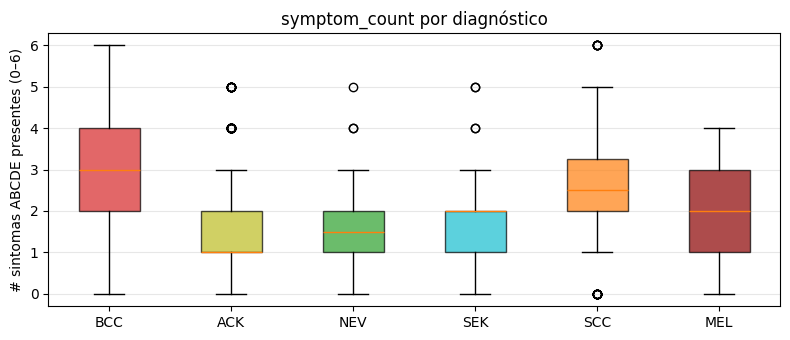

In [8]:
# Visualização rápida: symptom_count diferencia classes?
fig, ax = plt.subplots(figsize=(8, 3.5))
classes = ['BCC','ACK','NEV','SEK','SCC','MEL']
data = [df.loc[df.diagnostic==c, 'symptom_count'] for c in classes]
bp = ax.boxplot(data, labels=classes, patch_artist=True)
colors = ['#d62728','#bcbd22','#2ca02c','#17becf','#ff7f0e','#8b0000']
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax.set_ylabel('# sintomas ABCDE presentes (0–6)')
ax.set_title('symptom_count por diagnóstico')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Split agrupado por paciente — `StratifiedGroupKFold`

> **Regra inegociável:** uma mesma lesão aparece em até 5 fotos e um mesmo
> paciente aparece em até ~6 lesões. Um split aleatório comum coloca fotos
> quase idênticas nos dois lados → métricas infladas.

### Estratégia

Usamos `StratifiedGroupKFold` duas vezes:

1. **Split externo (n_splits=5):** carva o `test` (~20% do dataset).
2. **Split interno sobre o restante (n_splits=5):** carva o `val` (~16% do total, ~20% do train+val).

Resultado aproximado: **64% train / 16% val / 20% test**, com:
- Zero overlap de `patient_id` entre splits (garantia do algoritmo)
- Distribuição de classes próxima ao original (estratificação)
- Seed fixa para reprodutibilidade


In [9]:
y       = df['diagnostic'].values
groups  = df['patient_id'].values

# --- Split externo: separa test (~20%) ---
sgkf_outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
trainval_idx, test_idx = next(sgkf_outer.split(df, y, groups))

df_trainval = df.iloc[trainval_idx].reset_index(drop=True)
df_test     = df.iloc[test_idx].reset_index(drop=True)

# --- Split interno sobre trainval: separa val (~20% do trainval ≈ 16% do total) ---
sgkf_inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
tv_y      = df_trainval['diagnostic'].values
tv_groups = df_trainval['patient_id'].values
train_rel, val_rel = next(sgkf_inner.split(df_trainval, tv_y, tv_groups))

df_train = df_trainval.iloc[train_rel].reset_index(drop=True)
df_val   = df_trainval.iloc[val_rel].reset_index(drop=True)

N = len(df)
print(f'train : {len(df_train):>5}  ({len(df_train)/N*100:.1f}%)')
print(f'val   : {len(df_val):>5}  ({len(df_val)/N*100:.1f}%)')
print(f'test  : {len(df_test):>5}  ({len(df_test)/N*100:.1f}%)')
print(f'total : {len(df_train)+len(df_val)+len(df_test):>5}')


train :  1470  (64.0%)
val   :   368  (16.0%)
test  :   460  (20.0%)
total :  2298


### Verificação do split

Três checagens obrigatórias:

1. **Zero overlap de `patient_id`** entre splits (senão há leak entre fotos do mesmo paciente).
2. **Contagem de MEL** em cada split — MEL tem só 52 amostras, é a classe que mais sofre se o split for ruim.
3. **Distribuição de classes** próxima ao original em cada split (estratificação efetiva).


In [10]:
# Check 1: zero overlap de patient_id
pids_train = set(df_train.patient_id)
pids_val   = set(df_val.patient_id)
pids_test  = set(df_test.patient_id)

assert len(pids_train & pids_val)  == 0, 'LEAK: paciente em train e val'
assert len(pids_train & pids_test) == 0, 'LEAK: paciente em train e test'
assert len(pids_val   & pids_test) == 0, 'LEAK: paciente em val e test'
print('✅ Zero overlap de patient_id entre splits')
print(f'   pacientes únicos: train={len(pids_train)}  val={len(pids_val)}  test={len(pids_test)}')


✅ Zero overlap de patient_id entre splits
   pacientes únicos: train=880  val=220  test=273


In [11]:
# Check 2 & 3: distribuição de classes por split
comp = pd.DataFrame({
    'total_n'   : df.diagnostic.value_counts(),
    'train_n'   : df_train.diagnostic.value_counts(),
    'val_n'     : df_val.diagnostic.value_counts(),
    'test_n'    : df_test.diagnostic.value_counts(),
    'train_%'   : df_train.diagnostic.value_counts(normalize=True).round(3)*100,
    'val_%'     : df_val.diagnostic.value_counts(normalize=True).round(3)*100,
    'test_%'    : df_test.diagnostic.value_counts(normalize=True).round(3)*100,
}).reindex(['BCC','ACK','NEV','SEK','SCC','MEL'])
print(comp.to_string())

# Sanity: MEL >= 5 em cada split (pelo menos algumas amostras para ter sinal)
for name, d in [('train', df_train), ('val', df_val), ('test', df_test)]:
    n_mel = (d.diagnostic == 'MEL').sum()
    assert n_mel >= 5, f'{name} tem só {n_mel} MELs (mínimo recomendado: 5)'
    print(f'✅ {name}: {n_mel} MELs')


            total_n  train_n  val_n  test_n  train_%  val_%  test_%
diagnostic                                                         
BCC             845      541    135     169     36.8   36.7    36.7
ACK             730      467    117     146     31.8   31.8    31.7
NEV             244      156     39      49     10.6   10.6    10.7
SEK             235      150     38      47     10.2   10.3    10.2
SCC             192      123     30      39      8.4    8.2     8.5
MEL              52       33      9      10      2.2    2.4     2.2
✅ train: 33 MELs
✅ val: 9 MELs
✅ test: 10 MELs


## 9. Pipeline sklearn — `ColumnTransformer`

Todas as transformações viram **um único objeto** `Pipeline` que:

- Ajusta **somente em `df_train`** (fit-on-train garantido pela API).
- Transforma `train`, `val` e `test` com a mesma lógica.
- É serializável (`joblib.dump`) para reutilização em inferência.

### Composição

| Coluna | Transformação |
|---|---|
| `age` | `StandardScaler` (única contínua) |
| `region` | `OneHotEncoder(min_frequency=10, handle_unknown='ignore')` |
| `itch, grew, hurt, changed, bleed, elevation, grew_unknown, changed_unknown, symptom_count` | passthrough (já são numéricas 0/1 ou inteiros pequenos) |

**Nota sobre `min_frequency=10`:** regiões raras como `SCALP` (18), `LIP` (23),
`FOOT` (16) são agrupadas em uma única categoria `infrequent_sklearn`. Isso
evita colunas OHE com 1–2 samples no treino (overfit garantido) e lida
automaticamente com categorias que só aparecem em val/test.

**Nota sobre `handle_unknown='ignore'`:** se uma categoria de região aparecer
em val/test mas não em train, ela recebe vetor de zeros em todas as colunas OHE
em vez de levantar erro.

---

### Decisão 5 — Por que OneHotEncoder em vez de codificar `region` como inteiro

Uma alternativa natural seria substituir as 14 colunas `region_*` por uma única
coluna inteira (`FACE=0, ARM=1, BACK=2, ...`). **Essa abordagem foi considerada
e rejeitada.** A justificativa está documentada abaixo com fontes oficiais.

#### Por que label encoding direto não funciona para `region`

`region` é uma variável **nominal** — não existe ordem natural entre `FACE`,
`ARM`, `BACK`, etc. Atribuir inteiros introduz uma ordem **fantasma** que não
existe no problema, e modelos (lineares **e** árvores, em graus diferentes)
tentam aprender essa ordem inexistente.

Citações diretas de fontes oficiais:

> *"[OrdinalEncoder] imposes an ordinal relationship where no such relationship
> may exist. This can cause problems and a one-hot encoding may be used instead."*
> — [scikit-learn — OrdinalEncoder docs](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html)

> *"Using ordinal encoding on unordered categories might be misleading to
> downstream statistical models because it falsely implies an ordering
> relationship (0 < 1 < 2, etc.) that doesn't exist in the data."*
> — [scikit-learn MOOC (Inria) — Encoding of categorical variables](https://inria.github.io/scikit-learn-mooc/python_scripts/03_categorical_pipeline.html)

**"Mas árvores não são imunes a ordens arbitrárias?"** — Meia-verdade. Uma
árvore sozinha pode encontrar splits úteis mesmo em variável mal-codificada,
mas precisa de até 13 splits em cadeia para isolar uma categoria que o OHE
isolaria com 1 split. Em Random Forest, com `max_features='sqrt'`, o bootstrap
de features reduz ainda mais a chance da árvore escolher a variável certa —
com OHE, cada categoria vira uma "chance" extra de ser selecionada por split.

O paper [*Lost in the Forest: Encoding categorical variables and the absent
levels problem* (Data Mining and Knowledge Discovery, 2024)](https://link.springer.com/article/10.1007/s10618-024-01019-w) documenta essa
patologia: label encoding em nominais distorce feature importance em RF e
degrada a generalização para categorias raras.

#### Por que target encoding também não vale neste caso

Target encoding (`sklearn.preprocessing.TargetEncoder`, disponível desde
sklearn 1.3) seria uma alternativa legítima — substitui `region` por uma
coluna única que codifica `P(maligno | region)`. Mas a documentação oficial
é explícita sobre quando usar:

> *"TargetEncoder encoding is typically suitable for **high cardinality**
> categorical variables as an alternative when OneHotEncoder creates too
> many features."*
> — [scikit-learn — Comparing Target Encoder with Other Encoders](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_target_encoder.html)

"High cardinality" na literatura começa a partir de ~50–100 categorias (CEPs,
IDs de produto). Com 14 categorias em `region`, estamos em **medium cardinality**
— exatamente a faixa em que OHE é oficialmente recomendado:

> *"OneHotEncoder encoding is suitable for low to medium cardinality categorical
> variables, both in supervised and unsupervised settings."*
> — [scikit-learn MOOC — Encoding of categorical variables](https://inria.github.io/scikit-learn-mooc/python_scripts/03_categorical_pipeline.html)

#### Decisão final: OHE com `min_frequency=10`

**Razões:**

1. `region` é nominal — label encoding está descartado pela literatura.
2. 14 categorias está em medium cardinality, faixa oficial do OHE.
3. `min_frequency=10` resolve o único problema real do OHE (categorias raras):
   agrupa `FOOT (16)`, `SCALP (18)`, `LIP (23)` em `region_infrequent_sklearn`.
4. Target encoding é overkill neste tamanho de vocabulário — sem ganho real,
   adiciona risco de leak se configurado incorretamente.
5. **Interpretabilidade:** `region_FACE` como feature separada permite leitura
   direta de feature importance / SHAP ("a face contribuiu +X para o score"),
   o que uma coluna numérica única destruiria.

**Observação sobre modelos com suporte nativo a categorical features.** Se no
futuro usarmos `LightGBM`, `CatBoost` ou `HistGradientBoostingClassifier`
(desde sklearn 1.0) — que suportam splits categóricos nativos via
`categorical_feature=...` — a decisão pode ser revista: nesses modelos, um
inteiro + flag categórica é *melhor* que OHE porque o algoritmo faz splits
multivariados reais (`region ∈ {FACE, NOSE, EAR}`) em vez de splits ordinais.
Para Random Forest e SVM (baselines óbvios deste projeto), OHE é a escolha
correta.


In [12]:
NUMERIC_COLS     = ['age']
CATEGORICAL_COLS = ['region']
PASSTHROUGH_COLS = SYMPTOM_COLS + ['grew_unknown', 'changed_unknown', 'symptom_count']

preprocess = ColumnTransformer(
    transformers=[
        ('num',  StandardScaler(),                           NUMERIC_COLS),
        ('cat',  OneHotEncoder(min_frequency=10,
                               handle_unknown='ignore',
                               sparse_output=False),         CATEGORICAL_COLS),
        ('pass', 'passthrough',                              PASSTHROUGH_COLS),
    ],
    remainder='drop',     # tudo que não foi nomeado é descartado (patient_id, img_id, diagnostic, lesion_id)
    verbose_feature_names_out=False,
)

preprocess.fit(df_train)  # FIT SÓ NO TREINO — regra inegociável

# Nomes das features após transformação
feature_names = preprocess.get_feature_names_out().tolist()
print(f'Total de features após transformação: {len(feature_names)}')
for name in feature_names:
    print(f'  {name}')


Total de features após transformação: 24
  age
  region_ABDOMEN
  region_ARM
  region_BACK
  region_CHEST
  region_EAR
  region_FACE
  region_FOREARM
  region_HAND
  region_LIP
  region_NECK
  region_NOSE
  region_SCALP
  region_THIGH
  region_infrequent_sklearn
  itch
  grew
  hurt
  changed
  bleed
  elevation
  grew_unknown
  changed_unknown
  symptom_count


### Aplicação do pipeline nos 3 splits

`transform` (não `fit_transform`) em val e test — a regra de ouro.


In [13]:
X_train = preprocess.transform(df_train)
X_val   = preprocess.transform(df_val)
X_test  = preprocess.transform(df_test)

print(f'X_train: {X_train.shape}')
print(f'X_val  : {X_val.shape}')
print(f'X_test : {X_test.shape}')
print()
print('Estatísticas de X_train (após transformação):')
print(pd.DataFrame(X_train, columns=feature_names).describe().round(3).T)


X_train: (1470, 24)
X_val  : (368, 24)
X_test : (460, 24)

Estatísticas de X_train (após transformação):
                            count   mean    std    min    25%   50%    75%    max
age                        1470.0  0.000  1.000 -3.238 -0.572  0.11  0.731  2.095
region_ABDOMEN             1470.0  0.011  0.104  0.000  0.000  0.00  0.000  1.000
region_ARM                 1470.0  0.079  0.270  0.000  0.000  0.00  0.000  1.000
region_BACK                1470.0  0.112  0.315  0.000  0.000  0.00  0.000  1.000
region_CHEST               1470.0  0.127  0.333  0.000  0.000  0.00  0.000  1.000
region_EAR                 1470.0  0.031  0.174  0.000  0.000  0.00  0.000  1.000
region_FACE                1470.0  0.250  0.433  0.000  0.000  0.00  0.000  1.000
region_FOREARM             1470.0  0.163  0.369  0.000  0.000  0.00  0.000  1.000
region_HAND                1470.0  0.052  0.223  0.000  0.000  0.00  0.000  1.000
region_LIP                 1470.0  0.007  0.082  0.000  0.000  0.00  0.000 

## 10. Encoding da target

`LabelEncoder` simples. Ajustado no treino para fixar o mapeamento `classe → int`,
aplicado nos 3 splits.


In [14]:
le_target = LabelEncoder()
le_target.fit(df_train['diagnostic'])

y_train = le_target.transform(df_train['diagnostic'])
y_val   = le_target.transform(df_val['diagnostic'])
y_test  = le_target.transform(df_test['diagnostic'])

print('Mapeamento de classes:')
for i, cls in enumerate(le_target.classes_):
    print(f'  {i} → {cls}')
print()
print(f'y_train shape: {y_train.shape}  distribuição: {np.bincount(y_train)}')
print(f'y_val   shape: {y_val.shape}  distribuição: {np.bincount(y_val)}')
print(f'y_test  shape: {y_test.shape}  distribuição: {np.bincount(y_test)}')


Mapeamento de classes:
  0 → ACK
  1 → BCC
  2 → MEL
  3 → NEV
  4 → SCC
  5 → SEK

y_train shape: (1470,)  distribuição: [467 541  33 156 123 150]
y_val   shape: (368,)  distribuição: [117 135   9  39  30  38]
y_test  shape: (460,)  distribuição: [146 169  10  49  39  47]


## 11. Persistência em disco

Salvamos os splits processados como **Parquet** (eficiente, tipado, preserva dtypes)
contendo:

- As features transformadas (X)
- A target codificada (`y`)
- O `patient_id` (para qualquer análise posterior por paciente)
- O `img_id` (para junção com features de PDI no próximo notebook — **essa é a chave de merge**)

E salvamos os artefatos do pipeline:

- `pipeline.joblib` — `ColumnTransformer` ajustado
- `label_encoder.joblib` — mapeamento de classes
- `feature_names.json` — lista ordenada dos nomes das colunas transformadas
- `split_info.json` — metadados dos splits para auditoria


In [15]:
def build_split_df(df_split, X_split, y_split):
    '''Monta um DataFrame com features + target + IDs para persistência.'''
    out = pd.DataFrame(X_split, columns=feature_names)
    out['y'] = y_split
    out['diagnostic'] = df_split['diagnostic'].values
    out['patient_id'] = df_split['patient_id'].values
    out['lesion_id']  = df_split['lesion_id'].values
    out['img_id']     = df_split['img_id'].values
    return out

train_out = build_split_df(df_train, X_train, y_train)
val_out   = build_split_df(df_val,   X_val,   y_val)
test_out  = build_split_df(df_test,  X_test,  y_test)

# Persistência
train_out.to_parquet(PROC_DIR / 'train.parquet', index=False)
val_out.to_parquet(  PROC_DIR / 'val.parquet',   index=False)
test_out.to_parquet( PROC_DIR / 'test.parquet',  index=False)

joblib.dump(preprocess, PROC_DIR / 'pipeline.joblib')
joblib.dump(le_target,  PROC_DIR / 'label_encoder.joblib')

with open(PROC_DIR / 'feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)

split_info = {
    'seed': SEED,
    'split_strategy': 'StratifiedGroupKFold (outer n=5 → test; inner n=5 → val)',
    'groups': 'patient_id',
    'stratify': 'diagnostic',
    'n_train': len(df_train),
    'n_val':   len(df_val),
    'n_test':  len(df_test),
    'n_features': len(feature_names),
    'class_mapping': {int(i): c for i, c in enumerate(le_target.classes_)},
    'dropped_columns': {
        'leak': LEAK_COLS,
        'mnar_block': MNAR_BLOCK,
    },
    'numeric_features':     NUMERIC_COLS,
    'categorical_features': CATEGORICAL_COLS,
    'passthrough_features': PASSTHROUGH_COLS,
}
with open(PROC_DIR / 'split_info.json', 'w') as f:
    json.dump(split_info, f, indent=2)

print('✅ Artefatos salvos em', PROC_DIR)
for p in sorted(PROC_DIR.iterdir()):
    size = p.stat().st_size
    unit = 'KB' if size < 1e6 else 'MB'
    val  = size/1024 if size < 1e6 else size/1e6
    print(f'  {p.name:22s}  {val:>7.1f} {unit}')


✅ Artefatos salvos em /home/fonsek/CODE/pad-ufes-skin-classification/data/processed/metadata
  feature_names.json          0.4 KB
  label_encoder.joblib        0.5 KB
  pipeline.joblib             3.6 KB
  split_info.json             1.0 KB
  test.parquet               29.7 KB
  train.parquet              55.3 KB
  val.parquet                27.3 KB


## 12. Sanity checks finais

Bateria completa antes de declarar o notebook como concluído:

1. Parquets legíveis e com shapes corretos.
2. Zero NaN em todas as features transformadas.
3. Nenhum paciente em mais de um split.
4. `img_id` único dentro de cada split (não há chave duplicada para o merge futuro).
5. Cada classe presente em todos os splits.


In [16]:
tr = pd.read_parquet(PROC_DIR / 'train.parquet')
vl = pd.read_parquet(PROC_DIR / 'val.parquet')
ts = pd.read_parquet(PROC_DIR / 'test.parquet')

# 1. Shapes
assert tr.shape[0] == len(df_train)
assert vl.shape[0] == len(df_val)
assert ts.shape[0] == len(df_test)
print('✅ Shapes corretos nos parquets')

# 2. Zero NaN nas features
for name, d in [('train', tr), ('val', vl), ('test', ts)]:
    n_na = d[feature_names].isnull().sum().sum()
    assert n_na == 0, f'{name}: {n_na} NaN encontrados'
print('✅ Zero NaN em todas as features')

# 3. Sem overlap de patient_id (redundante com a checagem anterior, mas confirmando via arquivo salvo)
assert len(set(tr.patient_id) & set(vl.patient_id)) == 0
assert len(set(tr.patient_id) & set(ts.patient_id)) == 0
assert len(set(vl.patient_id) & set(ts.patient_id)) == 0
print('✅ Zero overlap de patient_id')

# 4. img_id único dentro de cada split
for name, d in [('train', tr), ('val', vl), ('test', ts)]:
    assert d.img_id.is_unique, f'{name}: img_id duplicado'
print('✅ img_id único dentro de cada split (chave válida para merge com PDI)')

# 5. Todas as classes em todos os splits
for name, d in [('train', tr), ('val', vl), ('test', ts)]:
    classes = set(d.diagnostic.unique())
    missing = {'BCC','ACK','NEV','SEK','SCC','MEL'} - classes
    assert not missing, f'{name}: classes ausentes {missing}'
print('✅ Todas as 6 classes presentes em todos os splits')


✅ Shapes corretos nos parquets
✅ Zero NaN em todas as features
✅ Zero overlap de patient_id


✅ img_id único dentro de cada split (chave válida para merge com PDI)
✅ Todas as 6 classes presentes em todos os splits


## 13. Resumo executivo

```
┌─ INPUT ─────────────────────────────────────────────┐
│  data/raw/metadata.csv                              │
│  2298 linhas × 26 colunas                           │
│  13 colunas com ~35% missing em bloco               │
└─────────────────────────────────────────────────────┘
                        ↓
┌─ DECISÕES APLICADAS ────────────────────────────────┐
│  DROP biopsed              (leak causal reverso)    │
│  DROP 13 cols MNAR         (outcome-dependent)      │
│  FEAT ENG  symptom_count   (soma ABCDE)             │
│  SPLIT  64/16/20 por paciente (StratifiedGroupKFold)│
│  OHE    region (min_frequency=10)                   │
│  SCALE  age (StandardScaler)                        │
│  FIT    só no treino                                │
│  IMPUTE nada (dataset já completo)                  │
└─────────────────────────────────────────────────────┘
                        ↓
┌─ OUTPUT ────────────────────────────────────────────┐
│  data/processed/metadata/                           │
│    train.parquet  val.parquet  test.parquet         │
│    pipeline.joblib  label_encoder.joblib            │
│    feature_names.json  split_info.json              │
└─────────────────────────────────────────────────────┘
```

### Próximo passo

`03_preprocessamento_pdi.ipynb` — pipeline de imagem (hair removal,
color constancy, segmentação Otsu com ROI) que usa os **mesmos splits**
(carregando `train/val/test.parquet` por `img_id`) para garantir que a
junção das duas fontes seja 1-para-1 e sem nenhum vazamento entre splits.
